<h1>CRIME</h1>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import requests
import matplotlib.pyplot as plt

<h2>pip install type list</h2>

In [2]:
pip install geopandas


[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install folium


[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


<h1>LIBRARIES</h1>

In [4]:
crimes = pd.read_csv('Datasets//Chicago_Crimes.csv')
crimes

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13439321,JH237424,04/14/2024 12:00:00 AM,040XX S PRAIRIE AVE,0890,THEFT,FROM BUILDING,APARTMENT,False,False,...,3,38.0,06,1178707.0,1878256.0,2024,12/21/2024 03:40:46 PM,41.821236,-87.619921,"(41.821236024, -87.619920712)"
1,13437420,JH234779,04/14/2024 12:00:00 AM,023XX W CERMAK RD,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,COMMERCIAL / BUSINESS OFFICE,False,False,...,25,31.0,26,1161210.0,1889347.0,2024,12/21/2024 03:40:46 PM,41.852052,-87.683801,"(41.852051675, -87.683800849)"
2,13428676,JH224478,04/14/2024 12:00:00 AM,043XX W LE MOYNE ST,0917,MOTOR VEHICLE THEFT,"CYCLE, SCOOTER, BIKE WITH VIN",STREET,False,False,...,36,23.0,07,1146960.0,1909501.0,2024,12/21/2024 03:40:46 PM,41.907640,-87.735587,"(41.907640473, -87.735587478)"
3,13429357,JH225293,04/14/2024 12:00:00 AM,039XX W ADAMS ST,143A,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,STREET,True,False,...,28,26.0,15,1150158.0,1898721.0,2024,12/21/2024 03:40:46 PM,41.877997,-87.724121,"(41.877997275, -87.724120826)"
4,13430098,JH226395,04/14/2024 12:00:00 AM,011XX W 112TH PL,0890,THEFT,FROM BUILDING,RESIDENCE,False,False,...,21,75.0,06,1170856.0,1830157.0,2024,12/21/2024 03:40:46 PM,41.689421,-87.650123,"(41.6894214, -87.650123247)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249118,13805239,JJ217509,04/12/2025 12:00:00 AM,029XX W LOGAN BLVD,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,APARTMENT,False,False,...,1,22.0,26,1156478.0,1917149.0,2025,04/19/2025 03:41:24 PM,41.928440,-87.700416,"(41.928439867, -87.700415972)"
249119,13804023,JJ215813,04/12/2025 12:00:00 AM,094XX S HARVARD AVE,0430,BATTERY,AGGRAVATED - OTHER DANGEROUS WEAPON,STREET,False,False,...,9,49.0,04B,1175694.0,1842631.0,2025,04/19/2025 03:41:24 PM,41.723545,-87.632040,"(41.723545182, -87.632039508)"
249120,13803926,JJ215943,04/12/2025 12:00:00 AM,084XX S VINCENNES AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,21,71.0,08B,1173850.0,1848976.0,2025,04/19/2025 03:41:24 PM,41.740998,-87.638606,"(41.74099774, -87.638606337)"
249121,13803475,JJ215338,04/12/2025 12:00:00 AM,050XX S ABERDEEN ST,0530,ASSAULT,AGGRAVATED - OTHER DANGEROUS WEAPON,STREET,True,False,...,20,61.0,04A,1169838.0,1871348.0,2025,04/19/2025 03:41:24 PM,41.802477,-87.652657,"(41.802477219, -87.652657244)"


<h1>filter_data</h1>

In [5]:
crimes.columns

Index(['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type',
       'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat',
       'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate',
       'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude',
       'Location'],
      dtype='object')

In [6]:
crimes['Primary Type'].unique()

array(['THEFT', 'OTHER OFFENSE', 'MOTOR VEHICLE THEFT',
       'WEAPONS VIOLATION', 'BATTERY', 'ASSAULT',
       'CRIMINAL SEXUAL ASSAULT', 'CRIMINAL TRESPASS', 'CRIMINAL DAMAGE',
       'DECEPTIVE PRACTICE', 'SEX OFFENSE', 'ROBBERY', 'NARCOTICS',
       'HOMICIDE', 'INTERFERENCE WITH PUBLIC OFFICER', 'BURGLARY',
       'ARSON', 'OFFENSE INVOLVING CHILDREN', 'INTIMIDATION',
       'PUBLIC PEACE VIOLATION', 'CONCEALED CARRY LICENSE VIOLATION',
       'KIDNAPPING', 'STALKING', 'LIQUOR LAW VIOLATION', 'PROSTITUTION',
       'GAMBLING', 'OBSCENITY', 'PUBLIC INDECENCY', 'HUMAN TRAFFICKING',
       'OTHER NARCOTIC VIOLATION', 'NON-CRIMINAL'], dtype=object)

In [7]:
crimes['Date'] = pd.to_datetime(crimes['Date'], errors='coerce')

/var/folders/4x/g0l0pk411w91t3wj50qy02qr0000gn/T/ipykernel_1134/373581355.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crimes['Date'] = pd.to_datetime(crimes['Date'], errors='coerce')


In [8]:
crimes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249123 entries, 0 to 249122
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ID                    249123 non-null  int64         
 1   Case Number           249123 non-null  object        
 2   Date                  249123 non-null  datetime64[ns]
 3   Block                 249123 non-null  object        
 4   IUCR                  249123 non-null  object        
 5   Primary Type          249123 non-null  object        
 6   Description           249123 non-null  object        
 7   Location Description  248266 non-null  object        
 8   Arrest                249123 non-null  bool          
 9   Domestic              249123 non-null  bool          
 10  Beat                  249123 non-null  int64         
 11  District              249123 non-null  int64         
 12  Ward                  249123 non-null  int64         
 13 

In [9]:
crimes['Year'] = crimes['Date'].dt.year
crimes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249123 entries, 0 to 249122
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ID                    249123 non-null  int64         
 1   Case Number           249123 non-null  object        
 2   Date                  249123 non-null  datetime64[ns]
 3   Block                 249123 non-null  object        
 4   IUCR                  249123 non-null  object        
 5   Primary Type          249123 non-null  object        
 6   Description           249123 non-null  object        
 7   Location Description  248266 non-null  object        
 8   Arrest                249123 non-null  bool          
 9   Domestic              249123 non-null  bool          
 10  Beat                  249123 non-null  int64         
 11  District              249123 non-null  int64         
 12  Ward                  249123 non-null  int64         
 13 

In [10]:
url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json?$limit=1000"
response = requests.get(url)
data = response.json()

<h1>Motorcycle Theft</h1>
<h1>Data Aggregation</h1>
<h1>Visualization of GeSpatial using FOLIUM</h1>

In [11]:
import folium
from folium.plugins import HeatMap

In [12]:
crimes.astype

<bound method NDFrame.astype of               ID Case Number       Date                  Block  IUCR  \
0       13439321    JH237424 2024-04-14    040XX S PRAIRIE AVE  0890   
1       13437420    JH234779 2024-04-14      023XX W CERMAK RD  2825   
2       13428676    JH224478 2024-04-14    043XX W LE MOYNE ST  0917   
3       13429357    JH225293 2024-04-14       039XX W ADAMS ST  143A   
4       13430098    JH226395 2024-04-14       011XX W 112TH PL  0890   
...          ...         ...        ...                    ...   ...   
249118  13805239    JJ217509 2025-04-12     029XX W LOGAN BLVD  2826   
249119  13804023    JJ215813 2025-04-12    094XX S HARVARD AVE  0430   
249120  13803926    JJ215943 2025-04-12  084XX S VINCENNES AVE  0486   
249121  13803475    JJ215338 2025-04-12    050XX S ABERDEEN ST  0530   
249122  13804512    JJ216668 2025-04-12    012XX W CARROLL AVE  0710   

               Primary Type                          Description  \
0                     THEFT        

In [13]:
crimes.columns.to_list()

['ID',
 'Case Number',
 'Date',
 'Block',
 'IUCR',
 'Primary Type',
 'Description',
 'Location Description',
 'Arrest',
 'Domestic',
 'Beat',
 'District',
 'Ward',
 'Community Area',
 'FBI Code',
 'X Coordinate',
 'Y Coordinate',
 'Year',
 'Updated On',
 'Latitude',
 'Longitude',
 'Location']

<h1 style='background:yellow;'>1. Where are the most crime-prione areas across the entire city of Chicago?</h1>

In [14]:
crimes['Primary Type'].value_counts().head(10)

Primary Type
THEFT                  59201
BATTERY                44579
CRIMINAL DAMAGE        27094
ASSAULT                22615
MOTOR VEHICLE THEFT    19604
OTHER OFFENSE          16781
DECEPTIVE PRACTICE     14991
BURGLARY                8443
ROBBERY                 8200
WEAPONS VIOLATION       7164
Name: count, dtype: int64

In [15]:
heat_data = crimes[['Latitude', 'Longitude']].dropna().sample(n=1000, random_state=42).values.tolist()

crime_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)
HeatMap(heat_data, radius=7).add_to(crime_map)
crime_map

In [16]:
crimes['Community Area'].value_counts().head(10)

Community Area
25.0    12814
8.0     11019
28.0    10489
32.0     8975
43.0     8190
24.0     7615
23.0     6936
29.0     6605
6.0      6585
71.0     6365
Name: count, dtype: int64

In [17]:
crimes['District'].value_counts().head(10)

District
8     16691
12    15355
1     14409
6     14157
19    13640
11    13423
4     13318
18    13118
2     12848
25    12664
Name: count, dtype: int64

<h1 style='background:yellow;'>2. Which locations have the highest concentration of crimes that led to an arrest?</h1>

In [18]:
arrests = crimes[crimes['Arrest'] == True][['Latitude', 'Longitude']].dropna().sample(n=1000, random_state=42).values.tolist()

arrest_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)
HeatMap(arrests, radius=7).add_to(arrest_map)
arrest_map

In [19]:
crimes[crimes['Arrest'] == True]['District'].value_counts().head(10)

District
11    3852
1     2621
8     2274
10    2118
25    2048
7     1887
6     1874
18    1768
9     1666
3     1611
Name: count, dtype: int64

<h1 style='background:yellow;'>3. Which areas in Chicago report the most theft-related crimes?</h1>

In [20]:
thefts = crimes[crimes['Primary Type'] == 'THEFT'][['Latitude', 'Longitude']].dropna().sample(n=1000, random_state=42).values.tolist()

theft_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)
HeatMap(thefts, radius=7).add_to(theft_map)
theft_map

In [21]:
crimes[crimes['Primary Type'] == 'THEFT']['District'].value_counts().head(10)

District
19    5367
18    5259
1     5164
12    4412
14    3292
8     3169
2     3128
25    3020
17    2406
6     2341
Name: count, dtype: int64

<h1 style='background:yellow;'>4. Where are physical violence and assault incidents most concentrated?</h1>

In [22]:
violent = crimes[crimes['Primary Type'].isin(['ASSAULT', 'BATTERY'])][['Latitude', 'Longitude']].dropna().sample(n=1000, random_state=42).values.tolist()

violence_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)
HeatMap(violent, radius=7).add_to(violence_map)
violence_map

In [23]:
crimes[crimes['Primary Type'].isin(['ASSAULT', 'BATTERY'])]['District'].value_counts().head(10)

District
8     4554
6     4516
3     4199
4     4141
11    3931
7     3622
25    3560
12    3484
2     3450
10    3352
Name: count, dtype: int64

<h1 style='background:yellow;'>5. In which areas do domestic-related crimes occur most frequently?</h1>

In [24]:
domestic = crimes[crimes['Domestic'] == True][['Latitude', 'Longitude']].dropna().sample(n=1000, random_state=42).values.tolist()

domestic_map = folium.Map(location=[41.8781, -87.6298], zoom_start=11)
HeatMap(domestic, radius=7).add_to(domestic_map)
domestic_map

In [25]:
crimes[crimes['Domestic'] == True]['District'].value_counts().head(10)

District
6     3915
4     3463
8     3388
3     3321
11    2911
7     2863
25    2650
5     2632
2     2589
15    2518
Name: count, dtype: int64

<h1 style='background:yellow;'>Insight 6:</h1>

In [26]:
df = pd.DataFrame(data)
df.head()

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,location,:@computed_region_awaf_s7ux,:@computed_region_6mkv_f3dw,:@computed_region_vrxf_vc4k,:@computed_region_bdys_3d7i,:@computed_region_43wa_7qmu,:@computed_region_rpca_8um6,:@computed_region_d9mm_jgwp,:@computed_region_d3ds_rm58,:@computed_region_8hcu_yrd4
0,13810685,JJ223732,2025-04-19T00:00:00.000,012XX W 81ST ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,"{'latitude': '41.746846571', 'longitude': '-87...",18,21554,70,575,13,59,20,233,17
1,13810918,JJ224363,2025-04-19T00:00:00.000,006XX N ST CLAIR ST,0710,THEFT,THEFT FROM MOTOR VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,"{'latitude': '41.892993568', 'longitude': '-87...",22,21182,37,159,36,6,14,74,2
2,13810623,JJ223947,2025-04-19T00:00:00.000,005XX W PERSHING RD,0820,THEFT,$500 AND UNDER,RESTAURANT,False,False,...,"{'latitude': '41.82353187', 'longitude': '-87....",26,14924,58,172,48,37,23,170,7
3,13810233,JJ223564,2025-04-19T00:00:00.000,059XX S CAMPBELL AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,"{'latitude': '41.785994409', 'longitude': '-87...",19,21867,64,111,2,58,13,269,16
4,13813701,JJ227839,2025-04-19T00:00:00.000,005XX E 40TH ST,1780,OFFENSE INVOLVING CHILDREN,OTHER OFFENSE,APARTMENT,False,True,...,"{'latitude': '41.821176924', 'longitude': '-87...",12,4301,4,625,9,36,24,104,8


<h1 style='background:yellow;'>Insight 7:</h1>

In [27]:
print(df.columns)

Index(['id', 'case_number', 'date', 'block', 'iucr', 'primary_type',
       'description', 'location_description', 'arrest', 'domestic', 'beat',
       'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate',
       'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude',
       'location', ':@computed_region_awaf_s7ux',
       ':@computed_region_6mkv_f3dw', ':@computed_region_vrxf_vc4k',
       ':@computed_region_bdys_3d7i', ':@computed_region_43wa_7qmu',
       ':@computed_region_rpca_8um6', ':@computed_region_d9mm_jgwp',
       ':@computed_region_d3ds_rm58', ':@computed_region_8hcu_yrd4'],
      dtype='object')


In [28]:
df.columns = df.columns.str.strip()

In [29]:
if pd.notna(df['latitude']).all() and pd.notna(df['longitude']).all():
    df = df[['Primary Type', 'Latitude', 'Longitude']].dropna()
    df['Latitude'] = df['Latitude'].astype(float)
    df['Longitude'] = df['Longitude'].astype(float)

<h1 style='background:yellow;'>Insight 8:</h1>

In [30]:
crime_map = folium.Map(location=[41.8781,-87.6298], zoom_start=11)

<h1 style='background:yellow;'>Insight 9:</h1>

In [43]:
for _, row in df.iterrows():
    if pd.notna(row['latitude']) and pd.notna(row['longitude']):
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=3,
            popup=row['primary_type'],
            fill=True,
            color='red',
            fill_opacity=0.7
        ).add_to(crime_map)

<h1 style='background:yellow;'>Insight 10:</h1>

In [32]:
crimes.columns.to_list()

['ID',
 'Case Number',
 'Date',
 'Block',
 'IUCR',
 'Primary Type',
 'Description',
 'Location Description',
 'Arrest',
 'Domestic',
 'Beat',
 'District',
 'Ward',
 'Community Area',
 'FBI Code',
 'X Coordinate',
 'Y Coordinate',
 'Year',
 'Updated On',
 'Latitude',
 'Longitude',
 'Location']

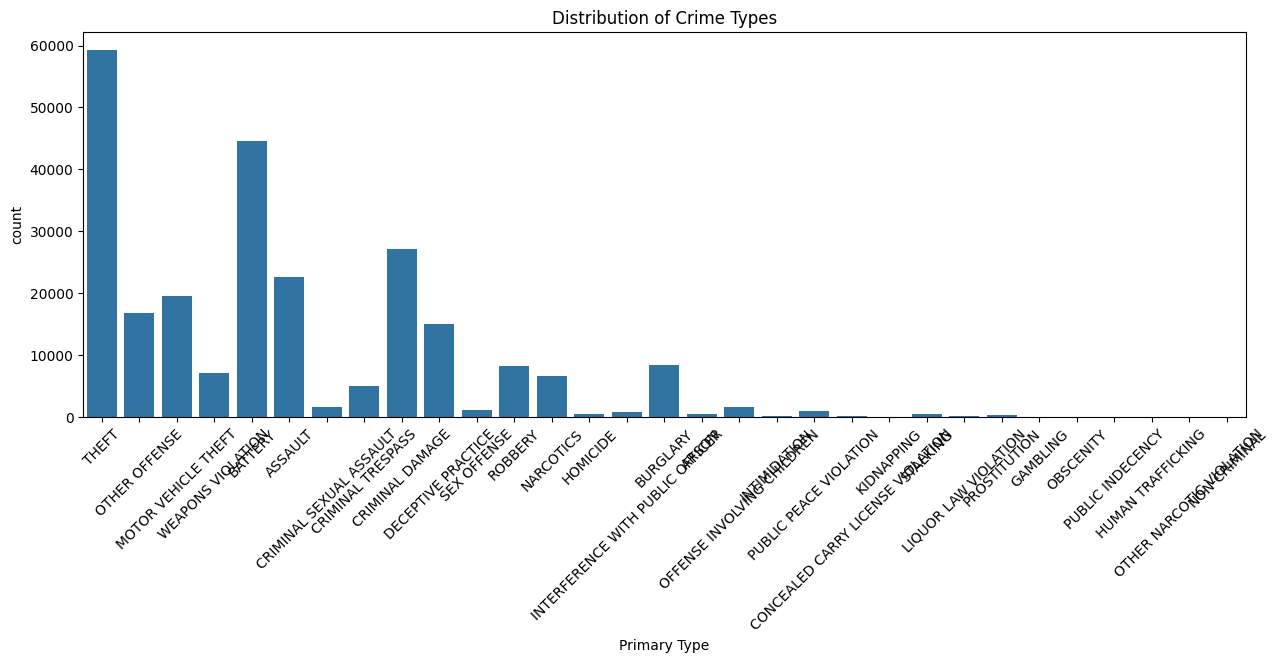

In [33]:
plt.figure(figsize=(15,5))
sns.countplot(x='Primary Type', data=crimes)
plt.title('Distribution of Crime Types')
plt.xticks(rotation=45)
plt.show()

<h1 style='background:yellow;'>Insight 11:</h1>

In [34]:
crimes.isnull().sum()
crimes.drop_duplicates(inplace=True)

In [35]:
print(crimes.describe())

                 ID                           Date           Beat  \
count  2.491230e+05                         249123  249123.000000   
mean   1.358652e+07  2024-10-03 08:31:57.251478528    1153.845634   
min    2.807300e+04            2024-04-14 00:00:00     111.000000   
25%    1.352322e+07            2024-07-06 13:45:30     533.000000   
50%    1.361560e+07            2024-09-27 03:00:00    1034.000000   
75%    1.370865e+07            2024-12-28 18:20:00    1732.000000   
max    1.381045e+07            2025-04-12 00:00:00    2535.000000   
std    6.473192e+05                            NaN     707.959752   

            District           Ward  Community Area  X Coordinate  \
count  249123.000000  249123.000000   249120.000000  2.490330e+05   
mean       11.308924      23.186823       36.238560  1.165309e+06   
min         1.000000       1.000000        1.000000  1.092647e+06   
25%         5.000000      10.000000       22.000000  1.153981e+06   
50%        10.000000      23.0000

/var/folders/4x/g0l0pk411w91t3wj50qy02qr0000gn/T/ipykernel_1134/1578659232.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  crime_trend = crimes.resample('M').size()


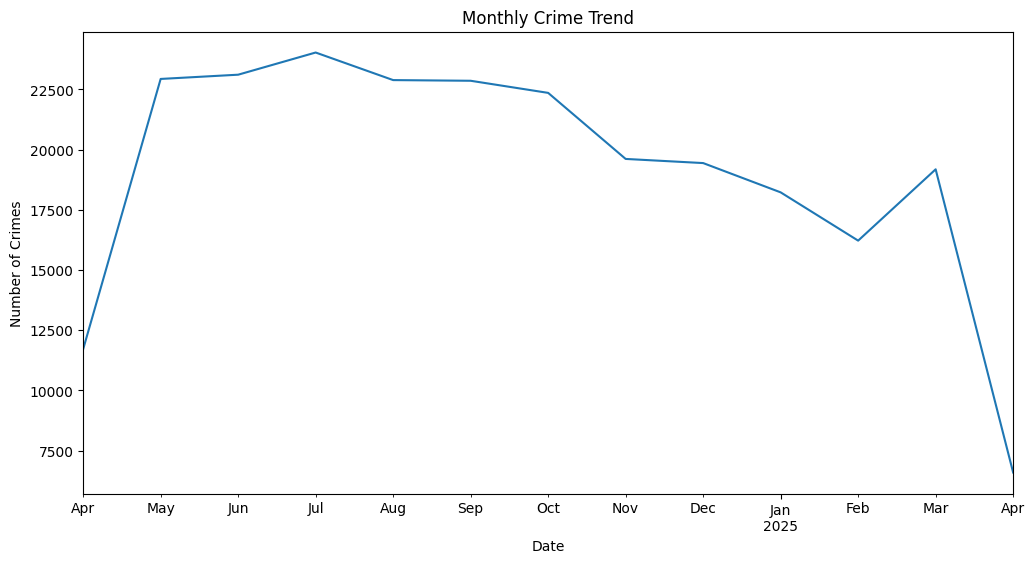

In [36]:
crimes['Date'] = pd.to_datetime(crimes['Date'])
crimes.set_index('Date', inplace=True)
crime_trend = crimes.resample('M').size()
crime_trend.plot(figsize=(12,6))
plt.title('Monthly Crime Trend')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.show()

In [37]:
import geopandas as gpd
# Load a map of Chicago and plot crime locations

<h2>Exploratory Data Analysis | C | Python | Jupyter Notebook</h2>